# 01 — Preprocessing (Stage A + Stage B)

Per `docs/05_processing_pipeline.md`. Uses the PDAL CLI via the `run_pipeline()` helper spelled out in `Claude.md`.

**Produces** (all 1 m, EPSG:6346, snapped to integer metres):
- `data/derivatives/dem_1m.tif` — TIN DEM from `Classification==2` ground points
- `data/derivatives/dsm_1m.tif` — max-Z DSM from first returns
- `data/derivatives/chm_1m.tif` — `DSM − DEM`, floored at 0
- `data/derivatives/ground_density.tif` — exact ground-return count per cell (quality mask)
- `data/derivatives/hillshade.tif` — az 315°, alt 45° (WhiteboxTools)
- `data/derivatives/wells_in_tile.gpkg` — reprojected PA DEP wells clipped to tile

In [1]:
from pathlib import Path
import json, subprocess, shutil, time
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA  = PROJECT / 'data' / 'files'
DERIV = PROJECT / 'data' / 'derivatives'
LOGS  = PROJECT / 'docs'
DERIV.mkdir(parents=True, exist_ok=True)

LAS_PATH  = DATA / 'output3.las'
WELLS_CSV = DATA / 'output_wells_2.csv'
PDAL_EXE  = shutil.which('pdal') or 'pdal'
assert LAS_PATH.exists(), LAS_PATH
assert WELLS_CSV.exists(), WELLS_CSV
print('PDAL:', PDAL_EXE)
print('LAS :', LAS_PATH)
print('CSV :', WELLS_CSV)
print('OUT :', DERIV)

PDAL: C:\Users\colto\miniconda3\Library\bin\pdal.EXE
LAS : C:\Users\colto\Documents\GitHub\lidar_project - Copy\data\files\output3.las
CSV : C:\Users\colto\Documents\GitHub\lidar_project - Copy\data\files\output_wells_2.csv
OUT : C:\Users\colto\Documents\GitHub\lidar_project - Copy\data\derivatives


## PDAL invocation helper — the `Claude.md` pattern

Every PDAL call goes through `run_pipeline()` so inputs, outputs, and errors show up in a single place for logging.

In [2]:
def run_pipeline(pipeline_dict, label='pipeline', timeout=600):
    tmp = DERIV / f'_tmp_{label}.json'
    with open(tmp, 'w') as f:
        json.dump(pipeline_dict, f, indent=2)
    t0 = time.time()
    result = subprocess.run(
        [PDAL_EXE, 'pipeline', str(tmp)],
        capture_output=True, text=True, timeout=timeout,
    )
    dt = time.time() - t0
    print(f'[{label}] rc={result.returncode} in {dt:.1f}s')
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
        raise RuntimeError(f'PDAL pipeline {label} failed')
    tmp.unlink(missing_ok=True)
    return result

# Grid derived from the LAS header so the pipeline works on any tile.
_pi = subprocess.run([PDAL_EXE, 'info', '--summary', str(LAS_PATH)],
                     capture_output=True, text=True)
import json as _json
_meta = _json.loads(_pi.stdout)['summary']['bounds']
X0 = float(np.floor(_meta['minx'])); Y0 = float(np.floor(_meta['miny']))
X1 = float(np.ceil (_meta['maxx'])); Y1 = float(np.ceil (_meta['maxy']))
RES = 1.0
W = int((X1 - X0) / RES)
H = int((Y1 - Y0) / RES)
TRANSFORM = from_origin(X0, Y1, RES, RES)
CRS_EPSG = 6346
print(f'grid: {W} x {H} cells @ {RES} m, snap=({X0},{Y0})-({X1},{Y1})')

grid: 1500 x 1500 cells @ 1.0 m, snap=(621000.0,4594500.0)-(622500.0,4596000.0)


## 1. DEM — Delaunay TIN over ground points (PDAL CLI)

In [3]:
DEM_PATH = DERIV / 'dem_1m.tif'
run_pipeline({
    'pipeline': [
        {'type': 'readers.las', 'filename': str(LAS_PATH)},
        {'type': 'filters.range', 'limits': 'Classification[2:2]'},
        {'type': 'filters.delaunay'},
        {'type': 'filters.faceraster',
         'resolution': RES, 'origin_x': X0, 'origin_y': Y0,
         'width': W, 'height': H},
        {'type': 'writers.raster', 'filename': str(DEM_PATH), 'data_type': 'float32'},
    ]
}, label='dem_tin')

with rasterio.open(DEM_PATH) as ds:
    dem = ds.read(1).astype(np.float32)
    dem_nodata = ds.nodata
    print('DEM :', ds.width, 'x', ds.height, 'nodata=', dem_nodata)
if dem_nodata is not None:
    dem = np.where(dem == dem_nodata, np.nan, dem)
print(f'  z: {np.nanmin(dem):.2f} - {np.nanmax(dem):.2f} m  (NaN {100*np.isnan(dem).mean():.3f}%)')

[dem_tin] rc=0 in 10.1s
DEM : 1500 x 1500 nodata= -9999.0
  z: 375.27 - 486.94 m  (NaN 0.000%)


## 2. DSM — max Z per cell of first returns

In [4]:
DSM_PATH = DERIV / 'dsm_1m.tif'
run_pipeline({
    'pipeline': [
        {'type': 'readers.las', 'filename': str(LAS_PATH)},
        {'type': 'filters.range', 'limits': 'ReturnNumber[1:1]'},
        {'type': 'writers.gdal', 'filename': str(DSM_PATH),
         'output_type': 'max', 'resolution': RES,
         'origin_x': X0, 'origin_y': Y0, 'width': W, 'height': H,
         'data_type': 'float32'},
    ]
}, label='dsm_max')

with rasterio.open(DSM_PATH) as ds:
    dsm = ds.read(1).astype(np.float32)
    dsm_nodata = ds.nodata
if dsm_nodata is not None:
    dsm = np.where(dsm == dsm_nodata, np.nan, dsm)
print(f'DSM z: {np.nanmin(dsm):.2f} - {np.nanmax(dsm):.2f} m  (NaN {100*np.isnan(dsm).mean():.3f}%)')

[dsm_max] rc=0 in 7.7s
DSM z: 375.31 - 511.22 m  (NaN 0.016%)


## 3. CHM = DSM − DEM (floored at 0)

In [5]:
CHM_PATH = DERIV / 'chm_1m.tif'
chm = dsm - dem
chm = np.where(np.isnan(dsm) | np.isnan(dem), np.nan, np.maximum(chm, 0.0)).astype(np.float32)

with rasterio.open(
    CHM_PATH, 'w', driver='GTiff', height=H, width=W, count=1,
    dtype='float32', crs=f'EPSG:{CRS_EPSG}', transform=TRANSFORM,
    nodata=-9999.0, tiled=True, compress='deflate', predictor=3,
) as ds:
    ds.write(np.where(np.isnan(chm), -9999.0, chm), 1)
print(f'CHM: p50={np.nanpercentile(chm,50):.2f}  p95={np.nanpercentile(chm,95):.2f}  max={np.nanmax(chm):.2f} m')
print('wrote', CHM_PATH.name)

CHM: p50=0.52  p95=21.54  max=39.65 m
wrote chm_1m.tif


## 4. Ground density — exact `count(class==2)` per cell

PDAL's `writers.gdal(output_type='count')` uses a search radius, so its counts bleed across cells. For the quality mask we want *exact* per-cell counts, which is a trivial `np.bincount` via `laspy`.

In [6]:
import laspy
las = laspy.read(str(LAS_PATH))
cls = np.asarray(las.classification)
xs = np.asarray(las.x)
ys = np.asarray(las.y)
mask = (cls == 2)
col = np.floor((xs[mask] - X0) / RES).astype(np.int64)
row = np.floor((Y1 - ys[mask]) / RES).astype(np.int64)
ok = (col >= 0) & (col < W) & (row >= 0) & (row < H)
flat = row[ok] * W + col[ok]
density = np.bincount(flat, minlength=H*W).reshape(H, W).astype(np.uint16)
print(f'density: sum={density.sum():,} expected={mask.sum():,} mean={density.mean():.2f} p95={np.percentile(density,95):.0f}')

DENS_PATH = DERIV / 'ground_density.tif'
with rasterio.open(
    DENS_PATH, 'w', driver='GTiff', height=H, width=W, count=1,
    dtype='uint16', crs=f'EPSG:{CRS_EPSG}', transform=TRANSFORM,
    nodata=0, tiled=True, compress='deflate',
) as ds:
    ds.write(density, 1)
print('wrote', DENS_PATH.name)
del las

density: sum=6,051,676 expected=6,051,709 mean=2.69 p95=6


wrote ground_density.tif


## 5. Hillshade — WhiteboxTools

In [7]:
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(str(DERIV))
wbt.set_verbose_mode(False)
HS_PATH = DERIV / 'hillshade.tif'
rc = wbt.hillshade(
    dem=str(DEM_PATH),
    output=str(HS_PATH),
    azimuth=315.0, altitude=45.0,
)
print('wbt.hillshade rc =', rc)
with rasterio.open(HS_PATH) as ds:
    hs = ds.read(1)
print('hillshade:', hs.dtype, 'min/max=', int(hs.min()), int(hs.max()))

wbt.hillshade rc = 0
hillshade: int16 min/max= 0 32749


## 6. Wells ingest (per `docs/02_data_dictionary_wells.md`)

In [8]:
from shapely.geometry import box
wells = pd.read_csv(WELLS_CSV)
USABLE = ['Well_ident', 'Well_name', 'Latitude', 'Longitude',
          'Location_n', 'Source', 'Data_file_date']
wells = wells[USABLE].dropna(subset=['Well_ident', 'Latitude', 'Longitude']).copy()
wells['Location_n'] = wells['Location_n'].str.strip().str.rstrip('.')

g = gpd.GeoDataFrame(
    wells,
    geometry=gpd.points_from_xy(wells['Longitude'], wells['Latitude']),
    crs='EPSG:4326',
).to_crs(epsg=CRS_EPSG)

BUF = 50.0
tile = box(X0 - BUF, Y0 - BUF, X1 + BUF, Y1 + BUF)
wells_in = g[g.within(tile)].drop_duplicates('Well_ident').reset_index(drop=True)
print(f'wells in tile (+{BUF:.0f} m buffer): {len(wells_in)} / {len(g)}')

WELLS_GPKG = DERIV / 'wells_in_tile.gpkg'
WELLS_GPKG.unlink(missing_ok=True)
wells_in.to_file(WELLS_GPKG, layer='wells', driver='GPKG')
print('wrote', WELLS_GPKG.name)

wells in tile (+50 m buffer): 107 / 107
wrote wells_in_tile.gpkg


## 7. Quick-look QA

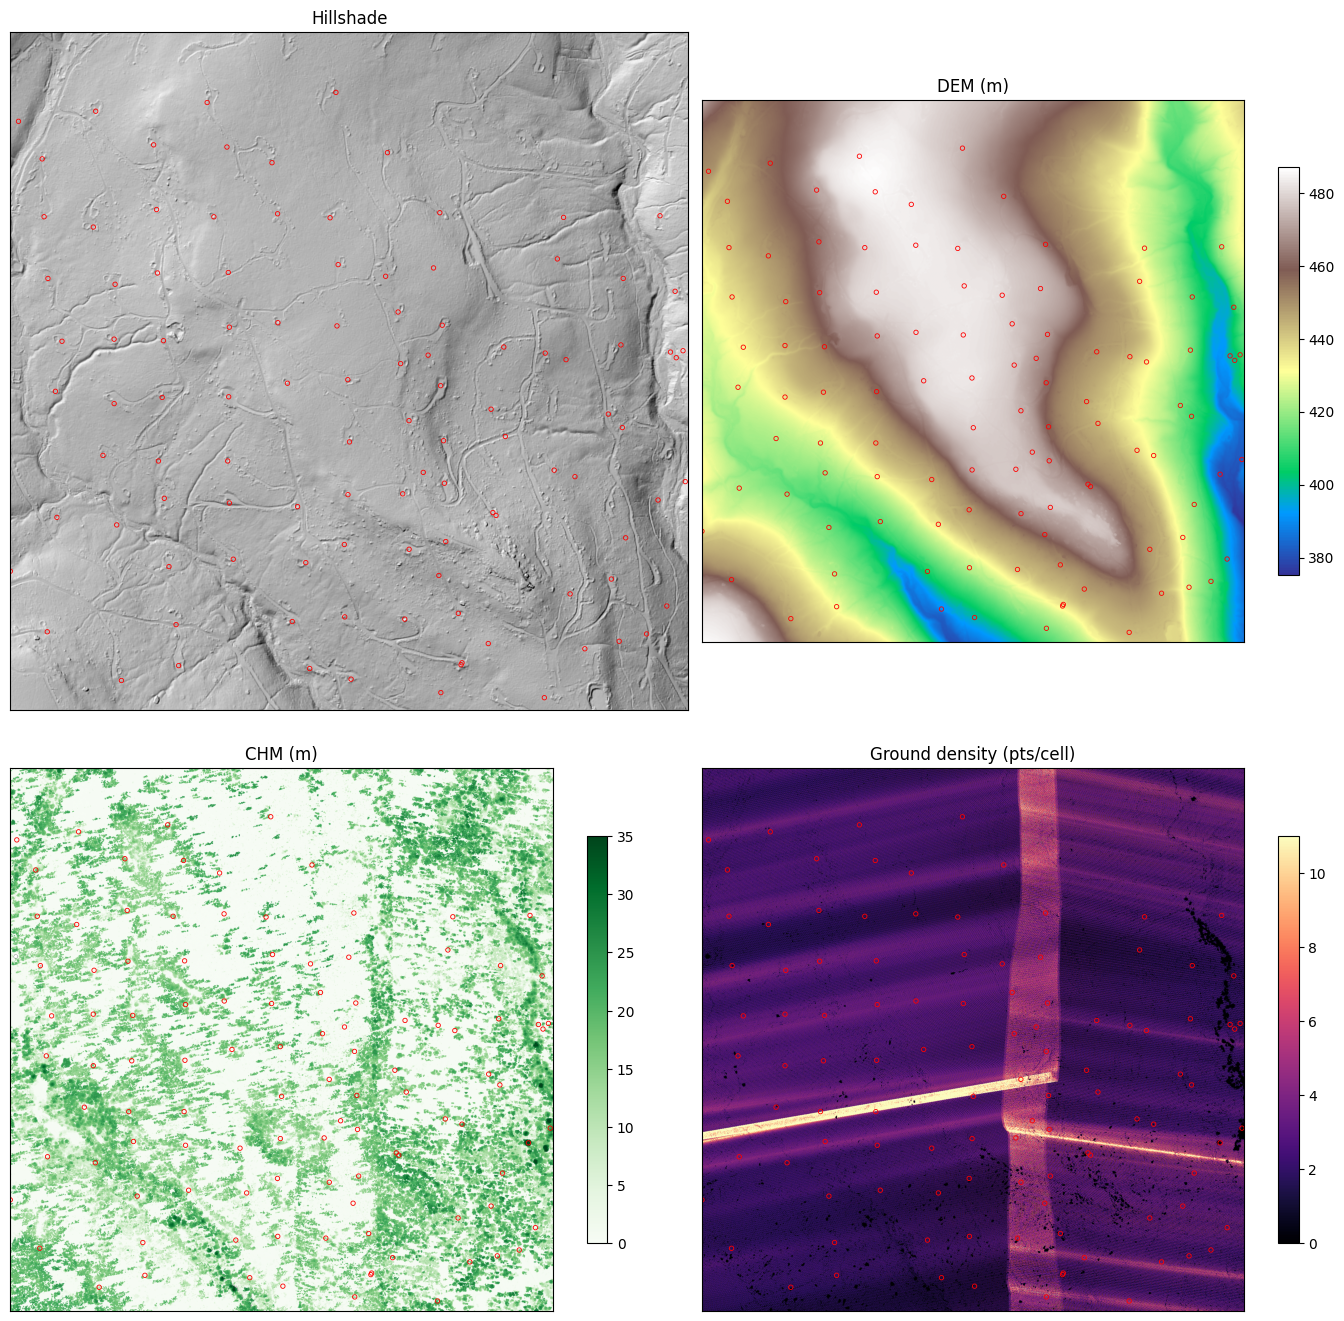

In [9]:
ext = (X0, X1, Y0, Y1)
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0,0].imshow(hs, cmap='gray', extent=ext, origin='upper'); axes[0,0].set_title('Hillshade')
im1 = axes[0,1].imshow(dem, cmap='terrain', extent=ext, origin='upper')
axes[0,1].set_title('DEM (m)'); plt.colorbar(im1, ax=axes[0,1], shrink=0.6)
im2 = axes[1,0].imshow(chm, cmap='Greens', extent=ext, origin='upper', vmin=0, vmax=35)
axes[1,0].set_title('CHM (m)'); plt.colorbar(im2, ax=axes[1,0], shrink=0.6)
im3 = axes[1,1].imshow(density, cmap='magma', extent=ext, origin='upper',
                        vmin=0, vmax=int(np.percentile(density,99)))
axes[1,1].set_title('Ground density (pts/cell)'); plt.colorbar(im3, ax=axes[1,1], shrink=0.6)
for ax in axes.flat:
    ax.scatter(wells_in.geometry.x, wells_in.geometry.y, s=10,
               facecolors='none', edgecolors='red', linewidths=0.6)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Append to `docs/analysis_log.md`

In [10]:
from datetime import datetime
ver = subprocess.run([PDAL_EXE, '--version'], capture_output=True, text=True).stdout
ver_line = next((l for l in ver.splitlines() if 'pdal' in l.lower() and 'version' not in l.lower()), '').strip()
entry = (
    f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage A+B complete (01_preprocessing)\n\n"
    f"- Tool: {ver_line or 'pdal ?'}, WhiteboxTools\n"
    f"- DEM : TIN (delaunay -> faceraster) on class=2. z {np.nanmin(dem):.2f} - {np.nanmax(dem):.2f} m, NaN {100*np.isnan(dem).mean():.3f}%\n"
    f"- DSM : max-Z first returns. z {np.nanmin(dsm):.2f} - {np.nanmax(dsm):.2f} m, NaN {100*np.isnan(dsm).mean():.3f}%\n"
    f"- CHM : DSM-DEM floored >= 0. p50={np.nanpercentile(chm,50):.2f} m, p95={np.nanpercentile(chm,95):.2f} m\n"
    f"- Ground density: np.bincount, exact/cell. mean {density.mean():.2f}, p95 {np.percentile(density,95):.0f}\n"
    f"- Hillshade: WBT az=315 alt=45\n"
    f"- Wells in tile (+50 m): {len(wells_in)} -> wells_in_tile.gpkg\n"
    f"- Grid: {W}x{H} @ {RES} m, EPSG:{CRS_EPSG}\n"
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)


## 2026-04-14 05:35 UTC — Stage A+B complete (01_preprocessing)

- Tool: pdal ?, WhiteboxTools
- DEM : TIN (delaunay -> faceraster) on class=2. z 375.27 - 486.94 m, NaN 0.000%
- DSM : max-Z first returns. z 375.31 - 511.22 m, NaN 0.016%
- CHM : DSM-DEM floored >= 0. p50=0.52 m, p95=21.54 m
- Ground density: np.bincount, exact/cell. mean 2.69, p95 6
- Hillshade: WBT az=315 alt=45
- Wells in tile (+50 m): 107 -> wells_in_tile.gpkg
- Grid: 1500x1500 @ 1.0 m, EPSG:6346



C:\Users\colto\AppData\Local\Temp\ipykernel_6684\4088703509.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage A+B complete (01_preprocessing)\n\n"
